In [4]:
%pip install pandas scikit-learn numpy matplotlib tensorflow

     ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
     ---------------------------------------- 0.1/11.3 MB 1.7 MB/s eta 0:00:07
      --------------------------------------- 0.2/11.3 MB 2.8 MB/s eta 0:00:05
     - -------------------------------------- 0.4/11.3 MB 2.9 MB/s eta 0:00:04
     -- ------------------------------------- 0.6/11.3 MB 3.5 MB/s eta 0:00:04
     -- ------------------------------------- 0.7/11.3 MB 3.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.8/11.3 MB 3.2 MB/s eta 0:00:04
     --- ------------------------------------ 1.0/11.3 MB 3.3 MB/s eta 0:00:04
     ---- ----------------------------------- 1.2/11.3 MB 3.3 MB/s eta 0:00:04
     ---- ----------------------------------- 1.4/11.3 MB 3.4 MB/s eta 0:00:03
     ----- ---------------------------------- 1.6/11.3 MB 3.4 MB/s eta 0:00:03
     ------ --------------------------------- 1.7/11.3 MB 3.6 MB/s eta 0:00:03
     ------ --------------------------------- 1.8/11.3 MB 3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.34.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import requests

url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2000-01-01&endtime=2026-04-12&minmagnitude=2.5&minlatitude=25&maxlatitude=40&minlongitude=70&maxlongitude=95&orderby=time-asc"
params = {
    "format": "csv",
    "starttime": "2000-01-01",
    "endtime": "2026-04-12",
    "minmagnitude": "2.5",
    "minlatitude": 25,
    "maxlatitude": 40,
    "minlongitude": 70,
    "maxlongitude": 95,
    "orderby": "time-asc"
}

print("Fetching data...")
response = requests.get(url, params=params)

# The fix: explicitly setting the encoding to utf-8
with open("earthquake_data.csv", "w", encoding='utf-8') as f:
    f.write(response.text)

print("Data acquired successfully! Check your folder for earthquake_data.csv")

Fetching data...
Data acquired successfully! Check your folder for earthquake_data.csv


In [26]:
# import pandas as pd
# from sklearn.preprocessing import MinMaxScaler
# import numpy as np

# # 1. Load the data
# df = pd.read_csv("earthquake_data.csv")

# # 2. Select only the features we need
# # We don't need 'id', 'place', or 'status' for the math
# features = ['time', 'latitude', 'longitude', 'depth', 'mag']
# df = df[features]

# # 3. Handle Missing Values
# # Earthquakes usually have all these, but just in case:
# df = df.dropna()

# # 4. Convert 'time' to a number
# # The AI can't read "2024-04-12T...". We convert it to a Unix Timestamp (seconds)
# df['time'] = pd.to_datetime(df['time']).view(np.int64) // 10**9

# # 5. Normalization (The most important part)
# # Why? Latitude is ~30, but Magnitude is ~4. 
# # The AI might think Latitude is "more important" just because the number is bigger.
# # We squash everything between 0 and 1.
# scaler = MinMaxScaler(feature_range=(0, 1))
# scaled_data = scaler.fit_transform(df)

# # Convert back to a clean DataFrame to see what happened
# df_scaled = pd.DataFrame(scaled_data, columns=features)

# print("Original Data Sample:")
# print(df.head(2))
# print("\nScaled Data Sample (Ready for AI):")
# print(df_scaled.head(2))

# # Save this for the next step
# df_scaled.to_csv("cleaned_earthquake_data.csv", index=False)
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Load and Sort
df = pd.read_csv("earthquake_data.csv")
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

# 2. Create "Smarter" Features
df['days_since'] = df['time'].diff().dt.total_seconds() / (24 * 3600)
df['days_since'] = df['days_since'].fillna(0)
# df['roll_mean'] = df['mag'].rolling(window=10).mean().fillna(df['mag'].mean())
# df['roll_max'] = df['mag'].rolling(window=10).max().fillna(df['mag'].max())
df['roll_mean'] = df['mag'].rolling(window=5).mean().fillna(df['mag'].mean())
df['roll_max'] = df['mag'].rolling(window=5).max().fillna(df['mag'].max())
df['mag_gradient'] = df['mag'].diff().fillna(0)

# 3. Select Features (8 columns total)
# features = ['time', 'latitude', 'longitude', 'depth', 'mag', 'days_since', 'roll_mean', 'roll_max']
# df_final = df[features]
features = ['time', 'latitude', 'longitude', 'depth', 'mag', 'days_since', 'roll_mean', 'roll_max', 'mag_gradient']
df_final = df[features]
df_final['time'] = pd.to_datetime(df_final['time']).view(np.int64) // 10**9

# 4. Scale everything between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_final)

C:\Users\Uday Kumar\AppData\Local\Temp\ipykernel_43680\4165445803.py:61: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_final['time'] = pd.to_datetime(df_final['time']).view(np.int64) // 10**9
C:\Users\Uday Kumar\AppData\Local\Temp\ipykernel_43680\4165445803.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['time'] = pd.to_datetime(df_final['time']).view(np.int64) // 10**9


In [27]:
# import numpy as np
# import pandas as pd

# # 1. Load the cleaned data
# df = pd.read_csv("cleaned_earthquake_data.csv")
# data = df.values  # Convert to a numpy array

# # 2. Define the Lookback period
# # Using the past 50 earthquakes to predict the next one
# lookback = 50
# X = []
# y = []

# for i in range(len(data) - lookback):
#     # Take rows i to i+lookback for features
#     X.append(data[i : i + lookback])
#     # Take the magnitude (column index 4) of the i+lookback row as target
#     y.append(data[i + lookback, 4])

# # 3. Convert to Numpy arrays
# X = np.array(X)
# y = np.array(y)

# # 4. Split into Training and Testing sets (80% train, 20% test)
# train_size = int(len(X) * 0.8)
# X_train, X_test = X[:train_size], X[train_size:]
# y_train, y_test = y[:train_size], y[train_size:]

# print(f"Features Shape (X_train): {X_train.shape}") 
# # Expected: (Samples, 50, 5) -> Samples, Time-steps, Features
# print(f"Target Shape (y_train): {y_train.shape}")
# 5. Create Sequences
lookback = 50
X, y = [], []

for i in range(len(scaled_data) - lookback):
    X.append(scaled_data[i : i + lookback])
    y.append(scaled_data[i + lookback, 4]) # Target is Magnitude at index 4

X, y = np.array(X), np.array(y)

# 6. Split Data
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 7. OVERSAMPLING: Make the model pay attention to Big Quakes
# We find sequences where the target magnitude is in the top 10% (scaled > 0.6)
high_mag_indices = np.where(y_train > 0.6)[0]
X_high = X_train[high_mag_indices]
y_high = y_train[high_mag_indices]

# Duplicate the big quakes 5 times to "shout" at the model
for _ in range(2):
    X_train = np.append(X_train, X_high, axis=0)
    y_train = np.append(y_train, y_high, axis=0)

print(f"Final training samples: {len(X_train)} (including boosted big quakes)")

Final training samples: 9914 (including boosted big quakes)


In [28]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout

# # 1. Initialize the Neural Network
# model = Sequential()

# # 2. Add the First LSTM Layer
# # units=50 is the number of neurons
# # input_shape=(50, 5) matches your (Lookback, Features)
# model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# model.add(Dropout(0.2)) # This randomly shuts off 20% of neurons to prevent "memorizing" (overfitting)

# # 3. Add the Second LSTM Layer
# model.add(LSTM(units=50, return_sequences=False))
# model.add(Dropout(0.2))

# # 4. Add the Output Layer
# # We only want 1 number (the predicted magnitude), so we use 1 unit
# model.add(Dense(units=1))

# # 5. Compile the Model
# # 'adam' is the most popular optimizer for beginners
# # 'mean_squared_error' is the math used to measure how "wrong" the model is
# model.compile(optimizer='adam', loss='mean_squared_error')

# # 6. Train the Model
# # epochs=20: The model sees the whole dataset 20 times
# # batch_size=32: The model looks at 32 sequences before updating itself
# print("Training started... this might take a minute or two.")
# history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# # 7. Save the Model
# model.save("earthquake_model.h5")
# print("Model trained and saved as earthquake_model.h5")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    # Change the '8' to '9' here
    LSTM(64, return_sequences=True, input_shape=(lookback, 9)), 
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

#model.compile(optimizer='adam', loss='mse')
optimizer = Adam(learning_rate=0.0005) 
model.compile(optimizer=optimizer, loss='mse')
# Train the model
print("Training smarter model...")
# model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))
# --- CHANGE epochs to 60 ---
model.fit(X_train, y_train, epochs=60, batch_size=32, validation_data=(X_test, y_test))

# Save for the dashboard
model.save("smarter_earthquake_model.h5")

Training smarter model...
Epoch 1/60


c:\Users\Uday Kumar\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0127 - val_loss: 0.0057
Epoch 2/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0108 - val_loss: 0.0046
Epoch 3/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0106 - val_loss: 0.0053
Epoch 4/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0103 - val_loss: 0.0045
Epoch 5/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0104 - val_loss: 0.0046
Epoch 6/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0103 - val_loss: 0.0046
Epoch 7/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0101 - val_loss: 0.0045
Epoch 8/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0102 - val_loss: 0.0055
Epoch 9/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0101 - val_loss: 0.0045
Epoch 10/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0101 - val_loss: 0.0045
Epoch 11/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0101 - val_loss: 0.0053
Epoch 12/60
310/310 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/ste

In [29]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import matplotlib.pyplot as plt

# # 1. Generate predictions for the entire test set
# y_pred_scaled = model.predict(X_test)

# # 2. Inverse scale both y_test and y_pred to get real magnitudes
# # We use the same 'dummy' trick as before to satisfy the scaler's 5-column shape
# def inverse_scale_magnitude(scaler, scaled_values):
#     dummy = np.zeros((len(scaled_values), 5))
#     dummy[:, 4] = scaled_values.flatten()
#     return scaler.inverse_transform(dummy)[:, 4]

# y_actual = inverse_scale_magnitude(scaler, y_test)
# y_predicted = inverse_scale_magnitude(scaler, y_pred_scaled)

# # 3. Calculate metrics
# mse = mean_squared_error(y_actual, y_predicted)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_actual, y_predicted)
# r2 = r2_score(y_actual, y_predicted)

# print(f"Results on Test Data:")
# print(f"RMSE: {rmse:.4f} Magnitude Units")
# print(f"MAE:  {mae:.4f} Magnitude Units")
# print(f"R2 Score: {r2:.4f}")
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Predict on the test set
y_pred_scaled = model.predict(X_test)

# 2. Updated Inverse Scaling for 8 Features
# Since magnitude was at index 4 in our ['time', 'lat', 'long', 'depth', 'mag', 'days', 'mean', 'max'] list
# def inverse_scale_mag(scaled_vals, scaler_obj):
#     # Create a dummy array with 8 columns (matching our new feature count)
#     dummy = np.zeros((len(scaled_vals), 8))
#     # Put our magnitude predictions into the 5th column (index 4)
#     dummy[:, 4] = scaled_vals.flatten()
#     # Inverse transform and pull out only the magnitude column
#     return scaler_obj.inverse_transform(dummy)[:, 4]
def inverse_scale_mag(scaled_vals, scaler_obj):
    # Change the '8' to '9'
    dummy = np.zeros((len(scaled_vals), 9)) 
    # Magnitude is still at index 4
    dummy[:, 4] = scaled_vals.flatten()
    return scaler_obj.inverse_transform(dummy)[:, 4]

# Convert both back to real magnitudes
y_actual = inverse_scale_mag(y_test, scaler)
y_predicted = inverse_scale_mag(y_pred_scaled, scaler)

# 3. Print the results
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
mae = mean_absolute_error(y_actual, y_predicted)
r2 = r2_score(y_actual, y_predicted)

print(f"--- Smarter Model Metrics ---")
print(f"RMSE: {rmse:.4f} (Average error in Magnitude)")
print(f"MAE:  {mae:.4f}")
print(f"R2 Score: {r2:.4f} (Higher is better)")

77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
--- Smarter Model Metrics ---
RMSE: 0.3662 (Average error in Magnitude)
MAE:  0.2694
R2 Score: -0.1042 (Higher is better)


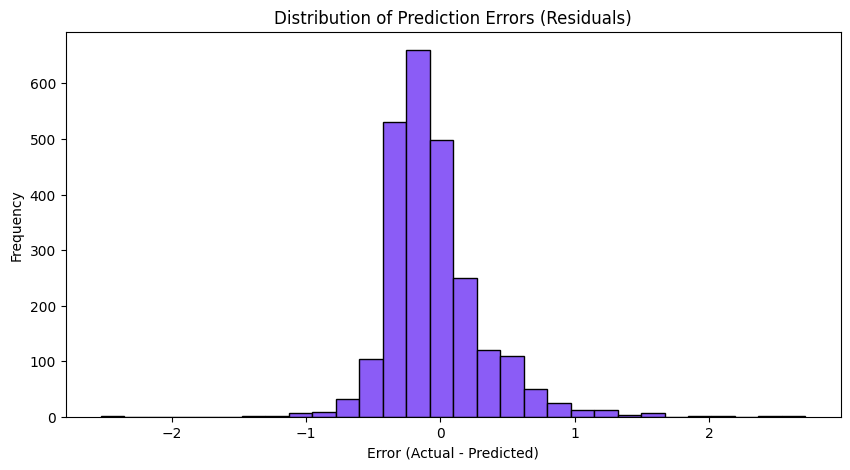

In [30]:
# plt.figure(figsize=(12, 6))
# plt.plot(y_actual[:100], label='Actual Magnitude', color='blue', alpha=0.7)
# plt.plot(y_predicted[:100], label='Predicted Magnitude', color='red', linestyle='--')
# plt.title('Comparison of Actual vs Predicted Earthquakes (First 100 Test Samples)')
# plt.xlabel('Sample Index')
# plt.ylabel('Magnitude')
# plt.legend()
# plt.show()
residuals = y_actual - y_predicted
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30, color='#8b5cf6', edgecolor='black')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

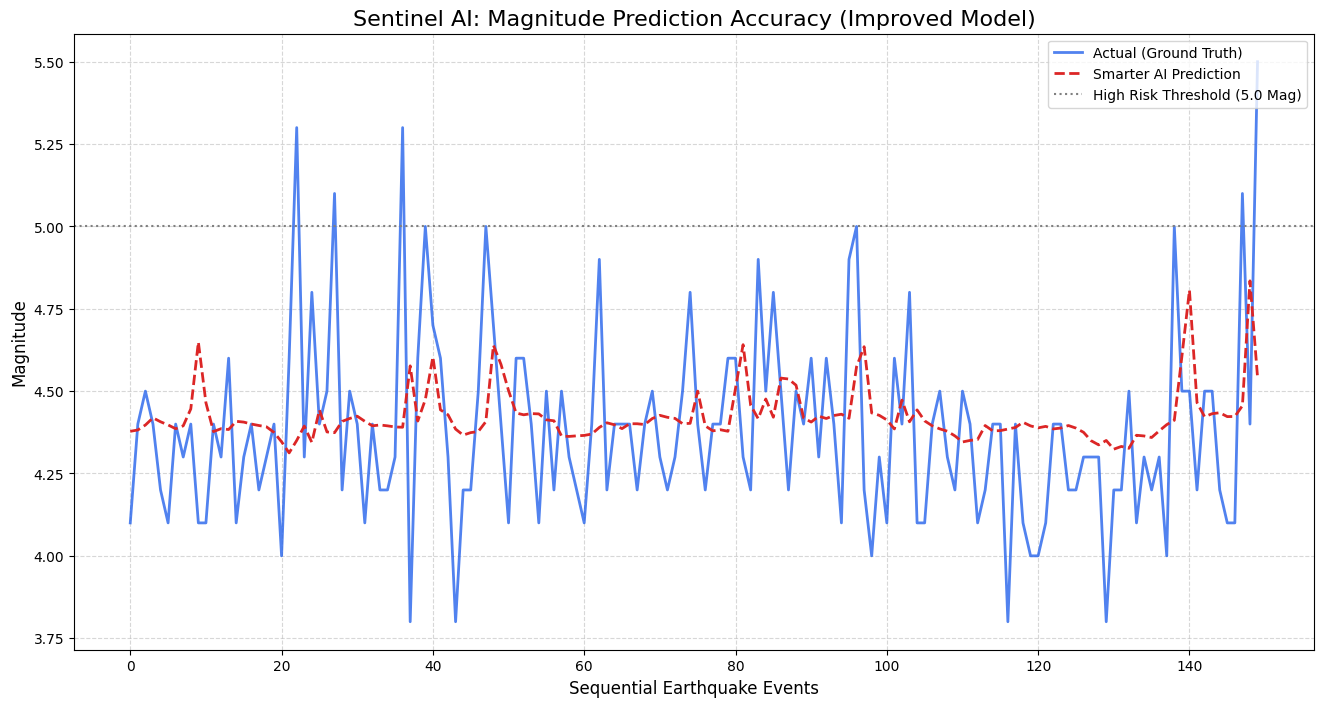

In [31]:
import matplotlib.pyplot as plt

# We plot a specific window (e.g., 100 to 250) to see the detail of the spikes
start, end = 100, 250 

plt.figure(figsize=(16, 8))
plt.plot(y_actual[start:end], label='Actual (Ground Truth)', color='#2563eb', linewidth=2, alpha=0.8)
plt.plot(y_predicted[start:end], label='Smarter AI Prediction', color='#dc2626', linestyle='--', linewidth=2)

# Adding a threshold line to show where "High Risk" begins
plt.axhline(y=5.0, color='gray', linestyle=':', label='High Risk Threshold (5.0 Mag)')

plt.title('Sentinel AI: Magnitude Prediction Accuracy (Improved Model)', fontsize=16)
plt.xlabel('Sequential Earthquake Events', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()